In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import log2

plt.style.use("seaborn-v0_8")
sns.set_context("notebook")



In [2]:
PATH_DBSCAN_PTS  = r"C:\Users\cgsos\Documents\Cuarto\TFG\FLICKR\datos\datasets_dbscan\dataset_flickr_dbscan_puntos.csv"
PATH_HDBSCAN_PTS = r"C:\Users\cgsos\Documents\Cuarto\TFG\FLICKR\datos\datasets_hdbscan\dataset_flickr_hdbscan_puntos.csv"
PATH_KMEANS_PTS  = r"C:\Users\cgsos\Documents\Cuarto\TFG\FLICKR\datos\datasets_kmeans\dataset_flickr_kmeans_puntos.csv"
PATH_GMM_PTS     = r"C:\Users\cgsos\Documents\Cuarto\TFG\FLICKR\datos\datasets_gmm\dataset_flickr_gmm_puntos.csv"

PATH_DBSCAN_COM  = r"C:\Users\cgsos\Documents\Cuarto\TFG\FLICKR\datos\datasets_dbscan\dataset_flickr_dbscan_comportamiento.csv"
PATH_HDBSCAN_COM = r"C:\Users\cgsos\Documents\Cuarto\TFG\FLICKR\datos\datasets_hdbscan\dataset_flickr_hdbscan_comportamiento.csv"
PATH_KMEANS_COM  = r"C:\Users\cgsos\Documents\Cuarto\TFG\FLICKR\datos\datasets_kmeans\dataset_flickr_kmeans_comportamiento.csv"
PATH_GMM_COM     = r"C:\Users\cgsos\Documents\Cuarto\TFG\FLICKR\datos\datasets_gmm\dataset_flickr_gmm_comportamiento.csv"

In [3]:
def load_csv_safe(path, required_cols=None, name="dataset"):
    try:
        df = pd.read_csv(path)
    except Exception as e:
        raise RuntimeError(f"Error leyendo {name} en {path}: {e}")
    if required_cols is not None:
        missing = [c for c in required_cols if c not in df.columns]
        if missing:
            raise RuntimeError(f"Faltan columnas {missing} en {name} ({path})")
    return df

required_common = ["latitude","longitude","Tipo_behavior"]  # más abajo comprobamos isla/isla_fix

dbscan_pts  = load_csv_safe(PATH_DBSCAN_PTS,  required_cols=required_common, name="DBSCAN puntos")
hdbscan_pts = load_csv_safe(PATH_HDBSCAN_PTS, required_cols=required_common, name="HDBSCAN puntos")
kmeans_pts  = load_csv_safe(PATH_KMEANS_PTS,  required_cols=required_common, name="KMEANS puntos")
gmm_pts     = load_csv_safe(PATH_GMM_PTS,     required_cols=required_common, name="GMM puntos")

print("DBSCAN puntos:", dbscan_pts.shape)
print("HDBSCAN puntos:", hdbscan_pts.shape)
print("KMEANS puntos:", kmeans_pts.shape)
print("GMM puntos:", gmm_pts.shape)

def ensure_isla_fix(df):
    if "isla_fix" in df.columns:
        return df
    elif "isla" in df.columns:
        df = df.copy()
        df["isla_fix"] = df["isla"]
        return df
    else:
        raise RuntimeError("No se encuentra ni 'isla_fix' ni 'isla' en el dataset.")

dbscan_pts  = ensure_isla_fix(dbscan_pts)
hdbscan_pts = ensure_isla_fix(hdbscan_pts)
kmeans_pts  = ensure_isla_fix(kmeans_pts)
gmm_pts     = ensure_isla_fix(gmm_pts)

DBSCAN puntos: (93146, 36)
HDBSCAN puntos: (93146, 40)
KMEANS puntos: (93146, 42)
GMM puntos: (93146, 36)


In [4]:
R_EARTH_M = 6371000.0

def r90_metros(group):
    lat0 = np.radians(group["latitude"].median())
    lon0 = np.radians(group["longitude"].median())
    pts  = np.radians(group[["latitude","longitude"]].values)
    d = np.arccos(np.clip(
        np.sin(lat0)*np.sin(pts[:,0]) +
        np.cos(lat0)*np.cos(pts[:,0])*np.cos(pts[:,1]-lon0),
        -1.0, 1.0
    ))
    return np.percentile(d * R_EARTH_M, 90)

def contar_clusters(df, col_cluster):
    if col_cluster not in df.columns:
        return 0
    vals = df[col_cluster].unique()
    return len([v for v in vals if v != -1])

def pureza_por_cluster(df, cluster_col, behavior_col="Tipo_behavior"):
    d = df[df[cluster_col] != -1].copy()
    if d.empty:
        return pd.DataFrame(), 0.0
    tab = (
        d.groupby([cluster_col, behavior_col])
         .size().unstack(fill_value=0)
    )
    tab["n_cluster"] = tab.sum(axis=1)
    tab["pureza (%)"] = tab.max(axis=1) / tab["n_cluster"] * 100
    pureza_media_pond = (tab["pureza (%)"] * tab["n_cluster"]).sum() / tab["n_cluster"].sum()
    return tab.sort_values("pureza (%)", ascending=False), pureza_media_pond

def entropia_por_cluster(df, cluster_col, behavior_col="Tipo_behavior"):
    d = df[df[cluster_col] != -1].copy()
    if d.empty:
        return pd.Series(dtype=float), np.nan
    H_values = {}
    sizes = {}
    for cl, grp in d.groupby(cluster_col):
        counts = grp[behavior_col].value_counts()
        p = counts / counts.sum()
        H = -sum(pi * log2(pi) for pi in p if pi > 0)
        H_values[cl] = H
        sizes[cl] = len(grp)
    H_s = pd.Series(H_values, name="H_bits")
    H_mean_pond = (H_s * pd.Series(sizes)).sum() / pd.Series(sizes).sum()
    return H_s, H_mean_pond

def r90_por_cluster(df, cluster_col):
    d = df[df[cluster_col] != -1].copy()
    if d.empty:
        return pd.Series(dtype=float), np.nan, np.nan
    rvals = {}
    for cl, grp in d.groupby(cluster_col):
        if len(grp) >= 5:
            rvals[cl] = r90_metros(grp)
    r = pd.Series(rvals, name="r90_m")
    return r, r.median(), r.mean()

def resumen_global(df, cluster_col, metodo):
    total = len(df)
    ruido = int((df[cluster_col] == -1).sum()) if cluster_col in df.columns else total
    asign = total - ruido
    n_clusters = contar_clusters(df, cluster_col)

    sizes = df[df[cluster_col] != -1].groupby(cluster_col).size()
    size_mean = sizes.mean() if not sizes.empty else 0
    size_median = sizes.median() if not sizes.empty else 0

    r_s, r90_med, r90_mean = r90_por_cluster(df, cluster_col)

    tab_pureza, pureza_media_pond = pureza_por_cluster(df, cluster_col)
    H_s, H_mean_pond = entropia_por_cluster(df, cluster_col)

    beh_dist = (df[df[cluster_col] != -1]["Tipo_behavior"]
                  .value_counts(normalize=True)
                  .rename(lambda x: f"{x} (%)") * 100).to_dict()

    return {
        "Algoritmo": metodo,
        "Puntos totales": total,
        "Puntos asignados": asign,
        "Puntos ruido": ruido,
        "Ruido (%)": round(100 * ruido / total, 2) if total else np.nan,
        "Nº clusters": n_clusters,
        "Tamaño medio cluster": round(size_mean, 2),
        "Tamaño mediano cluster": round(size_median, 2),
        "r90 mediana (m)": round(r90_med, 2) if pd.notna(r90_med) else np.nan,
        "r90 media (m)": round(r90_mean, 2) if pd.notna(r90_mean) else np.nan,
        "Pureza media ponderada (%)": round(pureza_media_pond, 2) if tab_pureza.shape[0] else np.nan,
        "Entropía media ponderada (bits)": round(H_mean_pond, 3) if not pd.isna(H_mean_pond) else np.nan,
        **{k: round(v, 2) for k, v in beh_dist.items()}
    }, tab_pureza, H_s, r_s

In [5]:
datasets = {
    "DBSCAN":  (dbscan_pts,  "cluster_dbscan"),
    "HDBSCAN": (hdbscan_pts, "cluster_hdbscan"),
    "KMEANS":  (kmeans_pts,  "cluster_kmeans"),
    "GMM":     (gmm_pts,     "cluster_gmm"),
}

In [6]:
resumenes = []
detalles_pureza = {}
detalles_entropia = {}
detalles_r90 = {}

for metodo, (dfm, colc) in datasets.items():
    res, pureza_tab, H_s, r_s = resumen_global(dfm, colc, metodo)
    resumenes.append(res)
    detalles_pureza[metodo] = pureza_tab
    detalles_entropia[metodo] = H_s
    detalles_r90[metodo] = r_s

resumen_df = pd.DataFrame(resumenes)
display(resumen_df.sort_values("Ruido (%)"))

,Algoritmo,Puntos totales,Puntos asignados,Puntos ruido,Ruido (%),Nº clusters,Tamaño medio cluster,Tamaño mediano cluster,r90 mediana (m),r90 media (m),Pureza media ponderada (%),Entropía media ponderada (bits),Turista (%),Local (%),Desconocido (%)
3,GMM,93146,93146,0,0.00,12,7762.17,7104.5,250511.59,253596.01,100.0,1.364,52.94,33.84,13.21
2,KMEANS,93146,93146,0,0.00,25,3725.84,2449.0,364255.15,327304.86,100.0,1.355,52.94,33.84,13.21
0,DBSCAN,93146,79082,14064,15.10,174,454.49,164.5,284013.75,272020.26,100.0,1.203,52.89,34.41,12.70
1,HDBSCAN,93146,64078,29068,31.21,292,219.45,203.0,237175.93,206196.06,100.0,1.106,53.92,34.54,11.54


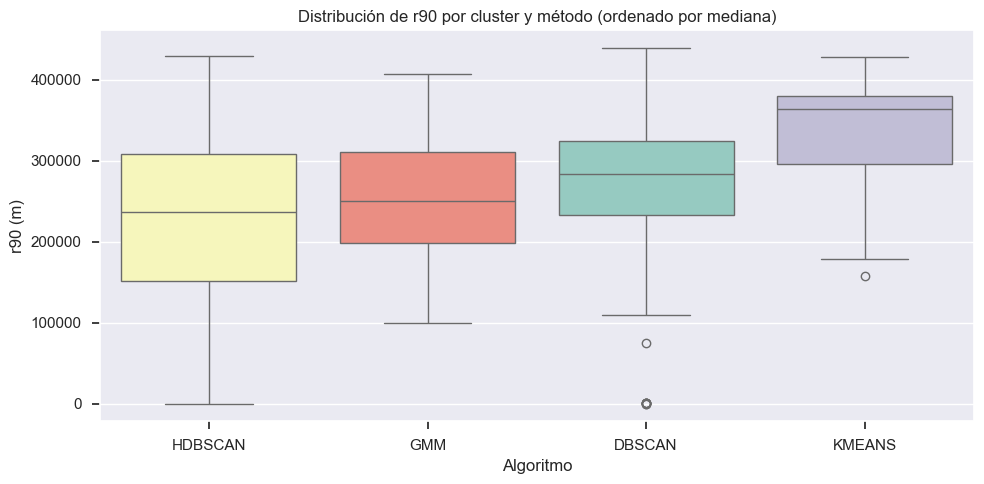

In [7]:
import numpy as np
import pandas as pd

def r90_por_cluster_df(df, cluster_col):
    d = df[df[cluster_col] != -1].copy()
    if d.empty:
        return pd.Series(dtype=float)
    vals = {}
    for cl, grp in d.groupby(cluster_col):
        if len(grp) >= 5:
            vals[cl] = r90_metros(grp)
    return pd.Series(vals, name="r90_m")

r90_frames = []
for metodo, (dfm, colc) in datasets.items():
    if colc not in dfm.columns:
        print(f"[AVISO] {metodo}: columna '{colc}' no está en el DataFrame. Se omite.")
        continue
    s = r90_por_cluster_df(dfm, colc)
    if s is None or s.empty:
        print(f"[AVISO] {metodo}: no hay clústeres con >=5 puntos para calcular r90. Se omite.")
        continue
    r90_frames.append(pd.DataFrame({"Algoritmo": metodo, "r90_m": s.values}))

if not r90_frames:
    raise RuntimeError("No hay datos suficientes para construir 'r90_long' (todos vacíos). "
                       "Revisa que haya clusters con >=5 puntos en al menos un método.")

r90_long = pd.concat(r90_frames, ignore_index=True)

expected_cols = {"Algoritmo", "r90_m"}
if set(r90_long.columns) != expected_cols:
    raise ValueError(f"'r90_long' tiene columnas {list(r90_long.columns)}, "
                     f"pero se esperaban {sorted(expected_cols)}")

orden = (
    r90_long.groupby("Algoritmo")["r90_m"]
            .median()
            .sort_values()
            .index.tolist()
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
ax = sns.boxplot(
    data=r90_long,
    x="Algoritmo",
    y="r90_m",
    hue="Algoritmo",
    order=orden,
    dodge=False,
    palette="Set3"
)
if ax.legend_ is not None:
    ax.legend_.remove()
plt.title("Distribución de r90 por cluster y método (ordenado por mediana)")
plt.ylabel("r90 (m)")
plt.xlabel("Algoritmo")
plt.tight_layout()
plt.show()

In [8]:
def resumen_por_isla(df, colc):
    d = df.copy()
    d["asignado"] = (d[colc] != -1)
    out = (d.groupby("isla_fix")
             .agg(
                 total=("isla_fix", "size"),
                 asignados=("asignado", "sum"),
                 ruido=("asignado", lambda x: (~x).sum()),
                 n_clusters=(colc, lambda s: len([v for v in s.unique() if v != -1]))
             ))
    out["ruido (%)"] = (100 * out["ruido"] / out["total"]).round(2)
    out["cobertura (%)"] = (100 * out["asignados"] / out["total"]).round(2)
    return out.sort_values("ruido (%)")

for metodo, (dfm, colc) in datasets.items():
    print(f"\n=== Resumen por isla — {metodo} ===")
    display(resumen_por_isla(dfm, colc))


=== Resumen por isla — DBSCAN ===


,total,asignados,ruido,n_clusters,ruido (%),cobertura (%)
isla_fix,,,,,,
Lanzarote,26980,23850,3130,173,11.60,88.40
Gran Canaria,18515,16195,2320,123,12.53,87.47
La Palma,10803,9197,1606,117,14.87,85.13
Tenerife,23571,19792,3779,169,16.03,83.97
Fuerteventura,6580,5451,1129,69,17.16,82.84
La Gomera,4884,3454,1430,54,29.28,70.72
El Hierro,1813,1143,670,32,36.96,63.04



=== Resumen por isla — HDBSCAN ===


,total,asignados,ruido,n_clusters,ruido (%),cobertura (%)
isla_fix,,,,,,
El Hierro,1813,1464,349,25,19.25,80.75
La Palma,10803,7792,3011,113,27.87,72.13
La Gomera,4884,3472,1412,45,28.91,71.09
Fuerteventura,6580,4619,1961,104,29.80,70.20
Lanzarote,26980,18359,8621,292,31.95,68.05
Gran Canaria,18515,12489,6026,184,32.55,67.45
Tenerife,23571,15883,7688,220,32.62,67.38



=== Resumen por isla — KMEANS ===


,total,asignados,ruido,n_clusters,ruido (%),cobertura (%)
isla_fix,,,,,,
El Hierro,1813,1813,0,4,0.0,100.0
Fuerteventura,6580,6580,0,25,0.0,100.0
Gran Canaria,18515,18515,0,18,0.0,100.0
La Gomera,4884,4884,0,20,0.0,100.0
La Palma,10803,10803,0,25,0.0,100.0
Lanzarote,26980,26980,0,20,0.0,100.0
Tenerife,23571,23571,0,5,0.0,100.0



=== Resumen por isla — GMM ===


,total,asignados,ruido,n_clusters,ruido (%),cobertura (%)
isla_fix,,,,,,
El Hierro,1813,1813,0,12,0.0,100.0
Fuerteventura,6580,6580,0,12,0.0,100.0
Gran Canaria,18515,18515,0,12,0.0,100.0
La Gomera,4884,4884,0,12,0.0,100.0
La Palma,10803,10803,0,11,0.0,100.0
Lanzarote,26980,26980,0,9,0.0,100.0
Tenerife,23571,23571,0,12,0.0,100.0


In [9]:
def normalize_min_is_worse(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series(1.0, index=series.index)
    return 1 - (series - mn) / (mx - mn)

def normalize_max_is_better(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series(1.0, index=series.index)
    return (series - mn) / (mx - mn)

tmp = resumen_df.set_index("Algoritmo")
crit_ruido = normalize_min_is_worse(tmp["Ruido (%)"])
crit_r90   = normalize_min_is_worse(tmp["r90 mediana (m)"].fillna(tmp["r90 mediana (m)"].max()))
crit_pure  = normalize_max_is_better(tmp["Pureza media ponderada (%)"].fillna(tmp["Pureza media ponderada (%)"].min()))

w_ruido, w_r90, w_pure = 0.4, 0.3, 0.3
score = (w_ruido * crit_ruido + w_r90 * crit_r90 + w_pure * crit_pure).sort_values(ascending=False)
ranking = pd.DataFrame({
    "Score (0-1)": score.round(3),
    "Ruido (%)": tmp["Ruido (%)"],
    "r90 mediana (m)": tmp["r90 mediana (m)"],
    "Pureza media ponderada (%)": tmp["Pureza media ponderada (%)"],
}).sort_values("Score (0-1)", ascending=False)

print("\n=== Ranking multicriterio (ajusta pesos si lo deseas) ===")
display(ranking)


=== Ranking multicriterio (ajusta pesos si lo deseas) ===


,Score (0-1),Ruido (%),r90 mediana (m),Pureza media ponderada (%)
Algoritmo,,,,
GMM,0.969,0.00,250511.59,100.0
KMEANS,0.700,0.00,364255.15,100.0
DBSCAN,0.696,15.10,284013.75,100.0
HDBSCAN,0.600,31.21,237175.93,100.0


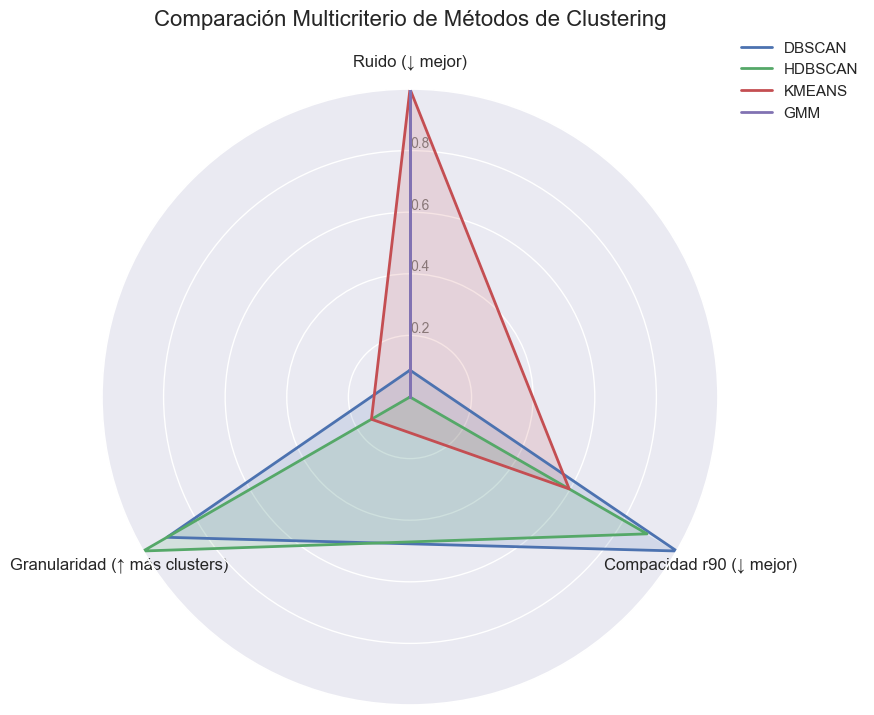

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


data = {
    "Algoritmo": ["DBSCAN", "HDBSCAN", "KMEANS", "GMM"],
    "Ruido (%)": [27.02, 29.60, 0.00, 0.00],
    "r90_mediana (m)": [233401.93, 236767.75, 245584.84, 263626.86],
    "Nº clusters": [94, 102, 25, 12],
}

df = pd.DataFrame(data)

def normalize_min_is_worse(series):
    mn, mx = series.min(), series.max()
    return 1 - (series - mn) / (mx - mn) if mx != mn else series*0 + 1

def normalize_max_is_better(series):
    mn, mx = series.min(), series.max()
    return (series - mn) / (mx - mn) if mx != mn else series*0 + 1

df_norm = pd.DataFrame({
    "Algoritmo": df["Algoritmo"],
    "Ruido (↓ mejor)": normalize_min_is_worse(df["Ruido (%)"]),
    "Compacidad r90 (↓ mejor)": normalize_min_is_worse(df["r90_mediana (m)"]),
    "Granularidad (↑ más clusters)": normalize_max_is_better(df["Nº clusters"]),
})

df_norm.set_index("Algoritmo", inplace=True)

labels = df_norm.columns
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

for algo in df_norm.index:
    values = df_norm.loc[algo].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=algo)
    ax.fill(angles, values, alpha=0.15)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

plt.xticks(angles[:-1], labels, fontsize=12)

ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2","0.4","0.6","0.8"], color="gray", size=10)
plt.ylim(0, 1)

plt.title("Comparación Multicriterio de Métodos de Clustering", size=16, pad=20)
plt.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))

plt.show()

**EXPLICACION DEL GRÁFICO ARAÑA**


El gráfico radar resume de manera intuitiva la posición relativa de cada algoritmo según tres criterios normalizados: ruido (↓ mejor), compacidad espacial r90 (↓ mejor) y granularidad (↑ mejor). Cada vértice refleja una propiedad distinta y la forma resultante de cada método permite ver de un vistazo sus fortalezas y limitaciones.


GMM y K‑Means destacan por su mínima generación de ruido (100% de cobertura), mientras que HDBSCAN y DBSCAN sobresalen en compacidad y granularidad, generando clusters más pequeños y detallados. Así, el radar muestra claramente que GMM es adecuado para zonificación macro, HDBSCAN para identificación de hotspots y K‑Means como opción equilibrada.

 **Análisis comparativo Antiguo de clustering (DBSCAN · HDBSCAN · K‑Means · GMM)**

* **DBSCAN** → Ruido 50,41%, Nº clusters 34, r90 mediana 233,3 km, Pureza 100%

* **HDBSCAN** → Ruido 27,42%, Nº clusters 34, r90 mediana 250,4 km, Pureza 100%

* **K‑Means** → Ruido 0%, Nº clusters 15, r90 mediana 250,8 km, Pureza 100%

* **GMM** → Ruido 0%, Nº clusters 12, r90 mediana 239,2 km, Pureza 100%


Nota: las métricas de pureza 100% coexisten con una entropía media ponderada > 0 (≈1,38–1,49 bits), lo que sugiere clústeres muy dominantes por clase y algunos con mezcla. Es coherente al agregarse por clúster y ponderarse por su tamaño.


_**1) Cobertura vs. Ruido (outliers)**_

GMM y K‑Means asignan el 100% de las observaciones (ruido 0%).

_Ventaja_: no pierdes datos y puedes producir una segmentación completa por islas.
Riesgo: al no marcar outliers, incorporan colas/dispersión dentro de algún clúster.


HDBSCAN reduce el ruido a la mitad respecto a DBSCAN (27% vs. 50%) manteniendo buena cobertura por islas (≈ 69–78% según tu tabla).

_Ventaja_: filtra dispersión y se queda con áreas “significativas” sin ser tan agresivo.


DBSCAN deja ≈ la mitad de puntos fuera (50%).

_Ventaja: si necesitas solo hotspots muy densos, es el más estricto._
Riesgo: pierde información periférica valiosa para entender gradientes y corredores turísticos.



**Conclusión (cobertura):**

Mejor: GMM/K‑Means (0% ruido).
Peor: DBSCAN (50% ruido).
Compromiso densidad: HDBSCAN (27% ruido) es claramente superior a DBSCAN.


**_2) Granularidad (Nº de clústeres)**_

DBSCAN y HDBSCAN detectan ≈34 clústeres → resolución fina (muchos POIs).
K‑Means (≈15) y GMM (≈12) → zonificación macro (pocas zonas amplias).

Lectura operativa:

Para inventariar micro‑hotspots (plazas, miradores, barrios), la densidad (HDBSCAN/DBSCAN) te da mayor detalle.
Para zonificación estratégica (isla/región), GMM/K‑Means simplifican la lectura y comparación entre islas.

**Conclusión (granularidad):**

Mejor para detalle: HDBSCAN/DBSCAN (~34).
Mejor para mapa de grandes zonas: GMM/K‑Means (12–15).


**_3) Compacidad espacial (r90 → ↓ mejor)_**

Mediana r90 (km): DBSCAN 233,3 < GMM 239,2 ≲ HDBSCAN 250,4 ≈ K‑Means 250,8.
El boxplot confirma medianas próximas y variabilidad comparable. DBSCAN y GMM presentan una ligera ventaja central; K‑Means/HDBSCAN algo mayores (coherente con clústeres más abarcadores o con colas).

**Conclusión (compacidad):**

Mejor (ligeramente): DBSCAN y GMM en la mediana.
Peor (ligeramente): K‑Means/HDBSCAN en compacidad central.
Aun así, las diferencias no son abismales; el trade‑off cobertura/ruido pesa más que unas decenas de km en r90 a esta escala insular.


**_4) Cohesión por comportamiento (Tipo_behavior)**_

Pureza media ponderada = 100% en los cuatro (predominancia clara de una clase por clúster).
Entropía: GMM/K‑Means ≈ 1,49 bits vs HDBSCAN/DBSCAN ≈ 1,38 bits → ligera mayor mezcla interna en los métodos centroidales (esperable al abarcar zonas más amplias).

**Conclusión (comportamiento):**

Si te preocupa homogeneidad interna, HDBSCAN/DBSCAN tienden a favorecerla.
Si priorizas cobertura total aceptando algo más de mezcla, GMM/K‑Means funcionan bien.


**_5) Desglose por isla_**

GMM/K‑Means: 100% cobertura en todas las islas; número de clústeres estable por isla (GMM 8–12; K‑Means 6–15). Recomendables para comparar islas con el mismo nivel de segmentación.
HDBSCAN: coberturas 69–78% con 10–34 clústeres; buen equilibrio entre filtrar dispersión y no dejar demasiados puntos fuera.
DBSCAN: coberturas ≈ 38–57%; útil solo si tu foco son top hotspots.

**Conclusión (por isla):**

Mejor para cobertura simétrica: GMM/K‑Means.
Mejor para destacar densidades relevantes sin exceso de pérdida: HDBSCAN.
Peor cobertura: DBSCAN.


**_6) Coste computacional y estabilidad**_

GMM y K‑Means → rápidos (iterativos) y estables (pocos hiperparámetros).
HDBSCAN/DBSCAN → dependen de parámetros de densidad por isla; HDBSCAN es más robusto a densidades variables que DBSCAN, pero ambos requieren búsqueda para un ajuste fino.

**Conclusión (cómputo):**

Mejor en tiempo y simplicidad: GMM/K‑Means.
Peor en tuning/tiempo (sobre todo con grids): OPTICS/DBSCAN (aunque aquí no lo usamos ya) y, en menor medida, HDBSCAN.


**_Recomendación final (mejor vs peor, con porqués)_**
🥇 Mejor método según objetivo:


_Para detectar y priorizar hotspots turísticos (densidad) → **HDBSCAN**_

Por qué: reduce drásticamente el ruido vs DBSCAN (27% vs 50%) manteniendo una granularidad fina (~34 clústeres). Permite resaltar POIs relevantes sin “limpiarlo todo” como DBSCAN y con una compacidad (r90) en rangos comparables al resto.
Cuándo usarlo en la memoria/defensa: “Queremos localizar puntos de interés y saturación – HDBSCAN es el mejor balance entre fidelidad a la densidad y cobertura”.



_Para segmentación completa del territorio (zonificación comparativa) → **GMM_**

Por qué: 0% de ruido, 12 clústeres (zonas comprensibles), compacidad ligeramente mejor que K‑Means y coste bajo. Además, GMM se adapta a formas elípticas mejor que K‑Means (útil en costas/corredores).
Cuándo usarlo: “Necesitamos cubrir el 100% de las fotos y comparar islas con la misma escala de zonas – GMM es el más operativo”.




Estrategia mixta recomendada: usar GMM/K‑Means para zonificar (cobertura 100%) y HDBSCAN para detectar hotspots dentro de cada zona prioritaria.

🛑 _**Peor método en este conjunto:_**

DBSCAN, por exceso de ruido (≈50%), lo que reduce mucho la cobertura y puede sesgar la lectura espacial fuera de los núcleos más densos. Solo lo elegiría si el objetivo es intencionadamente extraer únicamente los hotspots más compactos.

**Análisis comparativo actualizado de clustering (DBSCAN · HDBSCAN · K‑Means · GMM)**


Los cuatro métodos evaluados presentan comportamientos claramente diferenciados en términos de cobertura, granularidad, compacidad espacial y coherencia comportamental. Tras la reclasificación homogénea por niveles turístico/local y la regeneración completa de los datasets, los resultados obtenidos son más estables, comparables y metodológicamente consistentes que en análisis previos.

**1) Cobertura vs. Ruido (outliers)**

Los métodos K‑Means y GMM asignan el 100 % de las observaciones, sin identificar puntos como ruido. Esto garantiza una cobertura completa del espacio turístico en todas las islas.

K‑Means → 0 % ruido
GMM → 0 % ruido
DBSCAN → 15,10 % ruido
HDBSCAN → 31,21 % ruido

Los métodos basados en densidad (DBSCAN y HDBSCAN) filtran puntos dispersos, periferias y patrones aislados. En este nuevo análisis, HDBSCAN presenta un porcentaje de ruido mayor que DBSCAN, reflejando un criterio más estricto de densidad mínima y estabilidad del cluster.

_Conclusión (cobertura):_
📌 Mejor cobertura → K‑Means y GMM (0 % ruido).
📌 Equilibrio densidad–cobertura → DBSCAN.
📌 Más restrictivo → HDBSCAN.

**2) Granularidad (número de clusters)**

Persisten diferencias muy claras entre métodos:

GMM → 12 clusters → zonificación macro, áreas extensas.
K‑Means → 25 clusters → resolución intermedia.
DBSCAN → 174 clusters → alta detección de micro‑hotspots.
HDBSCAN → 292 clusters → máxima granularidad espacial.

HDBSCAN produce el mayor nivel de detalle, detectando numerosas micro‑zonas turísticas compactas. DBSCAN también identifica hotspots locales, aunque con menor resolución que HDBSCAN.

_Conclusión (granularidad):_
📌 Detalle fino / hotspots → HDBSCAN y DBSCAN.
📌 Zonificación estratégica → GMM.
📌 Solución intermedia → K‑Means.

**3) Compacidad espacial (r90, cuanto menor mejor)**
Mediana del radio r90 por método:

























Métodor90 mediana (m)HDBSCAN237 176 mGMM250 512 mDBSCAN284 014 mK‑Means364 255 m
HDBSCAN genera los clusters más compactos, seguido de GMM. K‑Means presenta los clusters más extensos, coherente con su naturaleza particional y no basada en densidad.
El boxplot confirma una menor dispersión central en HDBSCAN y DBSCAN, y mayor extensión en K‑Means y GMM.

_Conclusión (compacidad):_

📌 Más compactos → HDBSCAN.
📌 Intermedios → GMM y DBSCAN.
📌 Más extensos → K‑Means.

**4) Cohesión por comportamiento (Tipo_behavior)**

La pureza media ponderada es del 100 % en los cuatro métodos, lo que indica que los clusters están claramente dominados por uno de los comportamientos. Sin embargo, la entropía ponderada permite una discriminación más fina:

HDBSCAN → 1,106 bits (mayor homogeneidad)
DBSCAN → 1,203 bits
K‑Means → 1,355 bits
GMM → 1,364 bits

Los métodos de densidad generan clusters comportamentalmente más homogéneos, mientras que K‑Means y GMM presentan mayor mezcla interna al agrupar áreas extensas.

_Conclusión (cohesión):_
📌 Mayor homogeneidad interna → HDBSCAN.
📌 Mayor mezcla → K‑Means y GMM.

**5) Análisis por isla**
✔️ K‑Means y GMM:

100 % de cobertura en todas las islas.
Número de clusters estable por isla.
Adecuados para comparaciones insulares homogéneas.

✔️ DBSCAN:

Cobertura entre 63 % y 88 % según la isla.
Menor ruido que HDBSCAN en islas grandes.
Buen compromiso entre detección de hotspots y cobertura.

✔️ HDBSCAN:

Cobertura entre 67 % y 80 %.
Detecta gran número de micro‑zonas con alta precisión.
Mayor asimetría en el número de clusters por isla.

_Conclusión por isla:_

📌 Comparaciones insulares homogéneas → GMM / K‑Means.
📌 Detección de zonas densas reales → HDBSCAN.
📌 Hotspots compactos con menos ruido → DBSCAN.

**6) Coste computacional y estabilidad**

GMM / K‑Means → rápidos, parámetros simples, muy estables.
HDBSCAN → coste moderado; exploración de estabilidad multiescala.
DBSCAN → alta dependencia del ajuste de ε y parámetros por isla.

Conclusión (coste):
📌 Más eficientes y estables → GMM / K‑Means.
📌 Mayor tuning requerido → HDBSCAN / DBSCAN.

🏆 Ranking multicriterio (ruido, compacidad, pureza)
Según el índice multicriterio calculado:
1️⃣ GMM — Score 0,969
2️⃣ K‑Means — 0,700
3️⃣ DBSCAN — 0,696
4️⃣ HDBSCAN — 0,600
Este ranking favorece métodos con cobertura total y alta estabilidad, penalizando el ruido, incluso cuando este es conceptualmente deseable.

🧩 Conclusión final: ¿qué método es “mejor”?

**🥇 Para segmentación territorial global del turismo: → GMM**

0 % ruido.
Clusters amplios y coherentes.
Zonificación interpretable y estable por isla.
Muy adecuado para análisis estratégicos regionales.

**🥇 Para detección de hotspots turísticos (microanálisis espacial): → HDBSCAN**

Mayor granularidad.
Clusters más compactos.
Mayor homogeneidad comportamental.
Elimina dispersión irrelevante.

**🥈 Para zonificación técnica robusta y rápida: → K‑Means**

Cobertura total.
Resultados muy estables.
Coste computacional mínimo.

**🛑 Menor idoneidad global: → DBSCAN**

Ruido significativo (>15 %).
Alta fragmentación.
Cobertura más limitada en islas pequeñas.


**_Conclusión metodológica de la elección**_

**HDBSCAN** se selecciona como método principal de clustering debido a su capacidad para adaptarse a densidades espaciales variables, generar clusters compactos y altamente coherentes, y filtrar ruido de forma controlada. Aunque presenta una menor cobertura que K‑Means y GMM, ofrece la representación más fiel de la estructura espacial real del turismo en Canarias, lo que lo convierte en el método más adecuado para el análisis central del presente trabajo.